In [37]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

base = "../data/"
meta = "../data/MetaData/MetaData/"


In [38]:
# Cell 2: Load all CSVs (fixed paths)

train = pd.read_csv(base+"train.csv")
test = pd.read_csv(base+"test.csv")
sample_submission = pd.read_csv(base+"sample_submission.csv")

air_reserve = pd.read_csv(meta+"air_reserve.csv")
hpg_reserve = pd.read_csv(meta+"hpg_reserve.csv")
air_store_info = pd.read_csv(meta+"air_store_info.csv")
hpg_store_info = pd.read_csv(meta+"hpg_store_info.csv")
store_id_relation = pd.read_csv(meta+"store_id_relation.csv")
date_info = pd.read_csv(meta+"date_info.csv")


In [39]:
# Cell 3: Inspect schemas & head
dfs = {
    "train": train,
    "test": test,
    "sample_submission": sample_submission,
    "air_reserve": air_reserve,
    "hpg_reserve": hpg_reserve,
    "air_store_info": air_store_info,
    "hpg_store_info": hpg_store_info,
    "store_id_relation": store_id_relation,
    "date_info": date_info
}

for name, df in dfs.items():
    print(f"\n--- {name.upper()} ---")
    print(df.shape)
    print(df.head(3))
    print(df.info())



--- TRAIN ---
(239673, 3)
           air_store_id  visit_date  visitors
0  air_e3020992d5fe5dfd  2016-07-01        21
1  air_e3020992d5fe5dfd  2016-07-02        19
2  air_e3020992d5fe5dfd  2016-07-04         8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239673 entries, 0 to 239672
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   air_store_id  239673 non-null  object
 1   visit_date    239673 non-null  object
 2   visitors      239673 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 5.5+ MB
None

--- TEST ---
(12435, 2)
           air_store_id  visit_date
0  air_e3020992d5fe5dfd  2017-04-06
1  air_e3020992d5fe5dfd  2017-04-07
2  air_e3020992d5fe5dfd  2017-04-08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12435 entries, 0 to 12434
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   air_store_id  12435 non-null  object
 1   v

In [40]:
# Cell 4: Missing values overview
for name, df in dfs.items():
    print(f"\n--- {name.upper()} ---")
    print(df.isna().sum())



--- TRAIN ---
air_store_id    0
visit_date      0
visitors        0
dtype: int64

--- TEST ---
air_store_id    0
visit_date      0
dtype: int64

--- SAMPLE_SUBMISSION ---
id          0
visitors    0
dtype: int64

--- AIR_RESERVE ---
air_store_id        0
visit_datetime      0
reserve_datetime    0
reserve_visitors    0
dtype: int64

--- HPG_RESERVE ---
hpg_store_id        0
visit_datetime      0
reserve_datetime    0
reserve_visitors    0
dtype: int64

--- AIR_STORE_INFO ---
air_store_id      0
air_genre_name    0
air_area_name     0
latitude          0
longitude         0
dtype: int64

--- HPG_STORE_INFO ---
hpg_store_id      0
hpg_genre_name    0
hpg_area_name     0
latitude          0
longitude         0
dtype: int64

--- STORE_ID_RELATION ---
air_store_id    0
hpg_store_id    0
dtype: int64

--- DATE_INFO ---
calendar_date    0
day_of_week      0
holiday_flg      0
dtype: int64


## Visitors (Target Variable)

We start by exploring the distribution of visitors per restaurant/day.


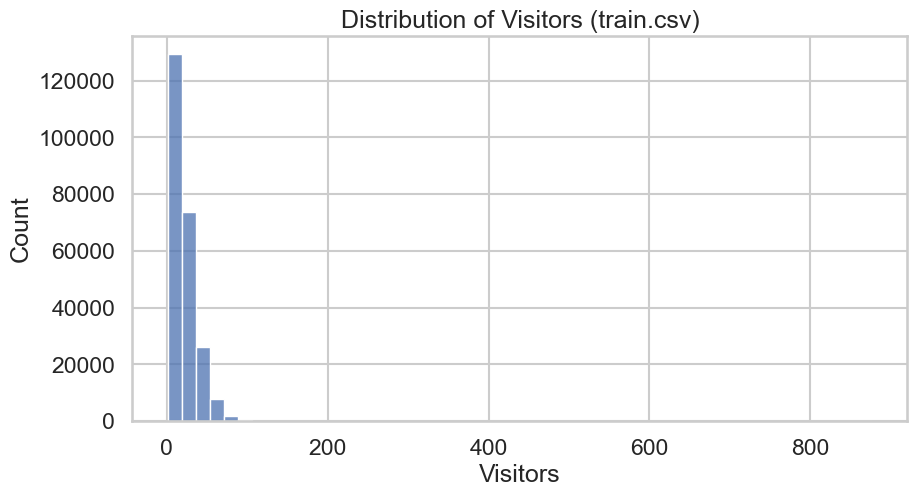

In [41]:
# Cell 5: Distribution of visitors
plt.figure(figsize=(10,5))
sns.histplot(train['visitors'], bins=50)
plt.title("Distribution of Visitors (train.csv)")
plt.xlabel("Visitors")
plt.ylabel("Count")
plt.show()


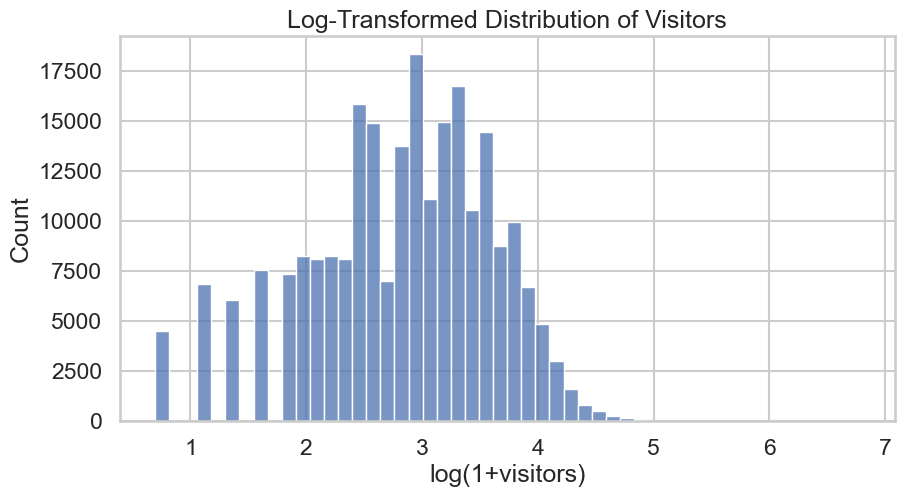

count    239673.000000
mean         20.952877
std          16.657248
min           1.000000
50%          17.000000
90%          43.000000
95%          52.000000
99%          73.000000
max         877.000000
Name: visitors, dtype: float64


In [42]:
# Cell 6: Log-transformed distribution
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(train['visitors']), bins=50)
plt.title("Log-Transformed Distribution of Visitors")
plt.xlabel("log(1+visitors)")
plt.ylabel("Count")
plt.show()

print(train['visitors'].describe(percentiles=[0.5,0.9,0.95,0.99]))


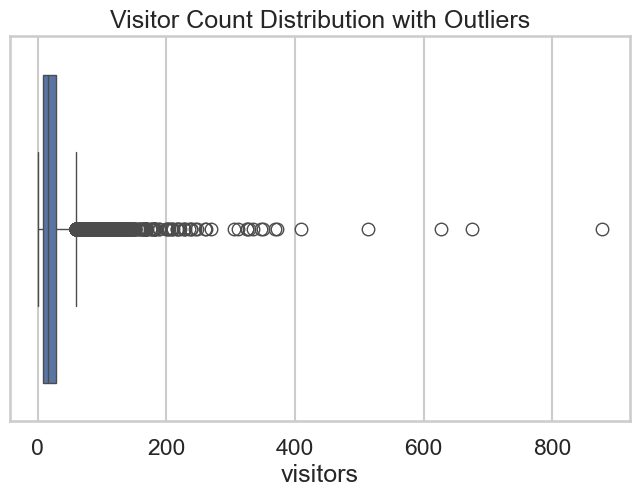

In [43]:
# Cell 7: Outlier view
plt.figure(figsize=(8,5))
sns.boxplot(x=train['visitors'])
plt.title("Visitor Count Distribution with Outliers")
plt.show()


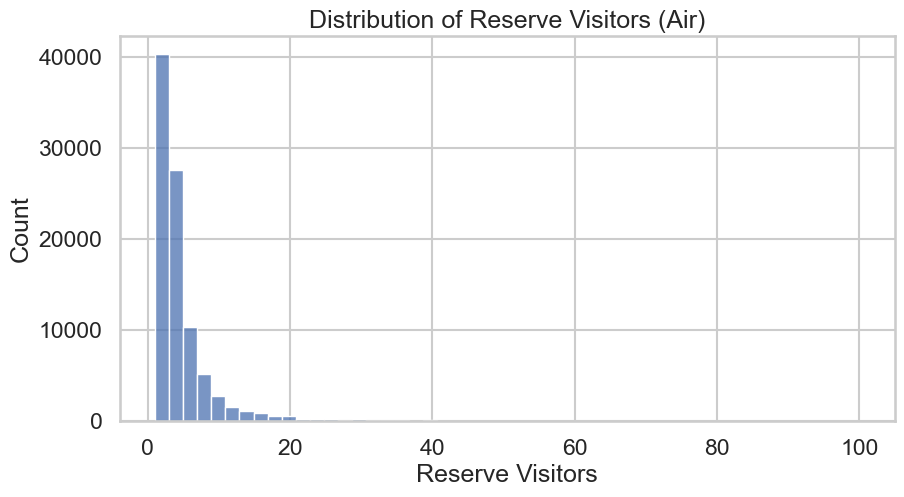

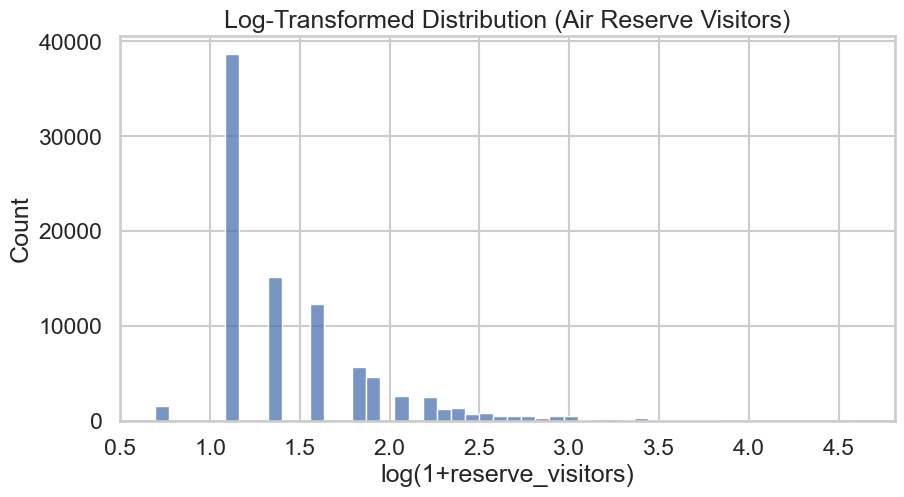

Air Reserve stats:
count    92378.000000
mean         4.481749
std          4.919669
min          1.000000
50%          3.000000
90%          8.000000
95%         13.000000
99%         27.000000
max        100.000000
Name: reserve_visitors, dtype: float64


In [50]:
# Check reservation visitors distribution (Air)
plt.figure(figsize=(10,5))
sns.histplot(air_reserve['reserve_visitors'], bins=50)
plt.title("Distribution of Reserve Visitors (Air)")
plt.xlabel("Reserve Visitors")
plt.ylabel("Count")
plt.show()

# Log transform for Air
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(air_reserve['reserve_visitors']), bins=50)
plt.title("Log-Transformed Distribution (Air Reserve Visitors)")
plt.xlabel("log(1+reserve_visitors)")
plt.ylabel("Count")
plt.show()

print("Air Reserve stats:")
print(air_reserve['reserve_visitors'].describe(percentiles=[0.5,0.9,0.95,0.99]))


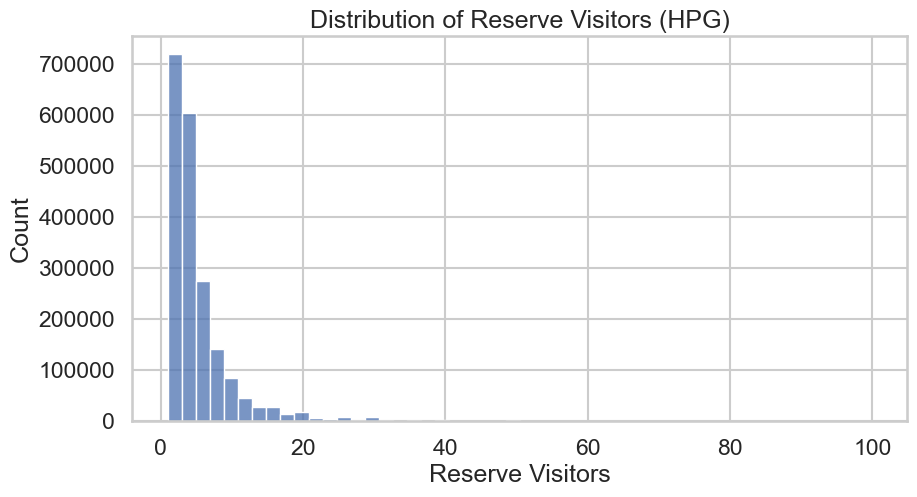

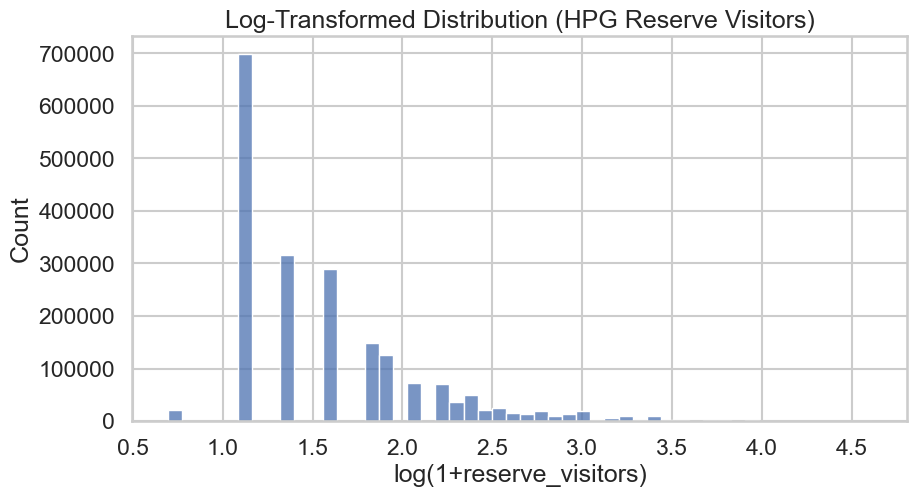

HPG Reserve stats:
count    2.000320e+06
mean     5.073785e+00
std      5.416172e+00
min      1.000000e+00
50%      3.000000e+00
90%      1.000000e+01
95%      1.500000e+01
99%      3.000000e+01
max      1.000000e+02
Name: reserve_visitors, dtype: float64


In [51]:
# Same for HPG
plt.figure(figsize=(10,5))
sns.histplot(hpg_reserve['reserve_visitors'], bins=50)
plt.title("Distribution of Reserve Visitors (HPG)")
plt.xlabel("Reserve Visitors")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(hpg_reserve['reserve_visitors']), bins=50)
plt.title("Log-Transformed Distribution (HPG Reserve Visitors)")
plt.xlabel("log(1+reserve_visitors)")
plt.ylabel("Count")
plt.show()

print("HPG Reserve stats:")
print(hpg_reserve['reserve_visitors'].describe(percentiles=[0.5,0.9,0.95,0.99]))


## Time Series Patterns

We now look at visitors over time, day-of-week trends, and holiday effects.


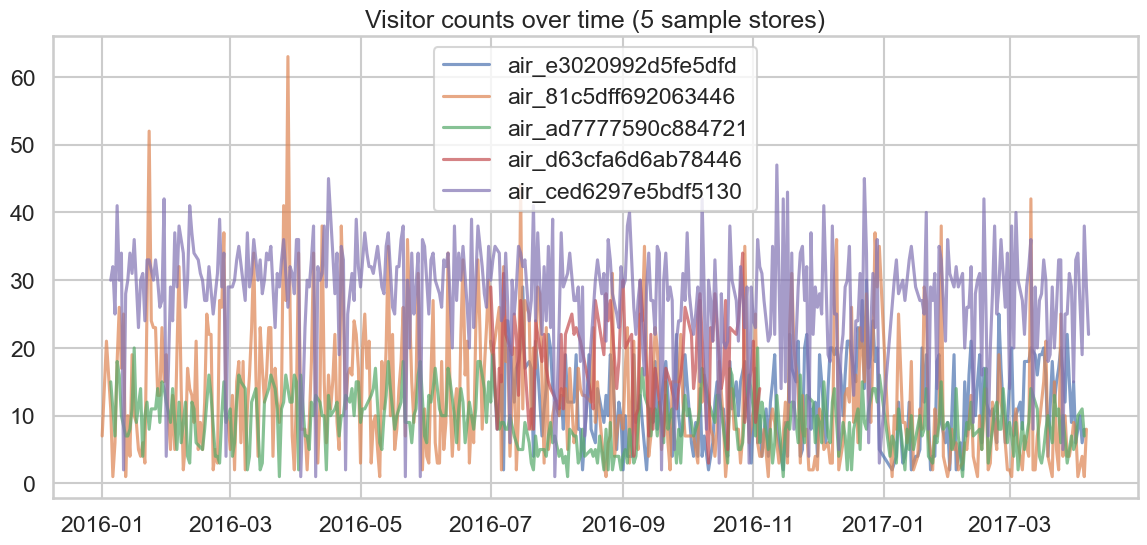

In [44]:
# Cell 8: Visitors over time (sample 5 stores)
train['visit_date'] = pd.to_datetime(train['visit_date'])
sample_stores = train['air_store_id'].unique()[:5]
train_sample = train[train['air_store_id'].isin(sample_stores)]

plt.figure(figsize=(14,6))
for sid in sample_stores:
    subset = train_sample[train_sample['air_store_id'] == sid]
    plt.plot(subset['visit_date'], subset['visitors'], label=sid, alpha=0.7)
plt.legend()
plt.title("Visitor counts over time (5 sample stores)")
plt.show()


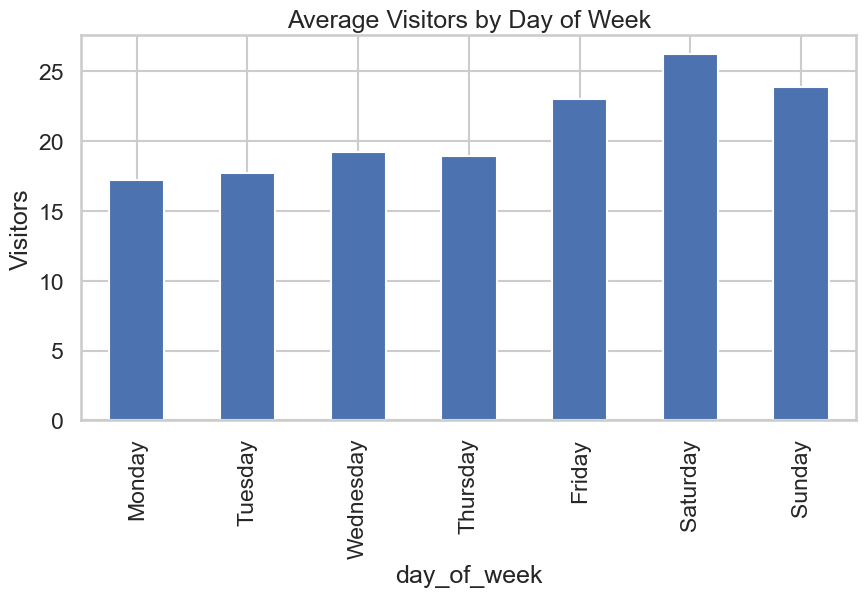

In [45]:
# Cell 9: Day-of-week average visitors
train['day_of_week'] = train['visit_date'].dt.day_name()
dow_visitors = train.groupby('day_of_week')['visitors'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,5))
dow_visitors.plot(kind="bar")
plt.title("Average Visitors by Day of Week")
plt.ylabel("Visitors")
plt.show()


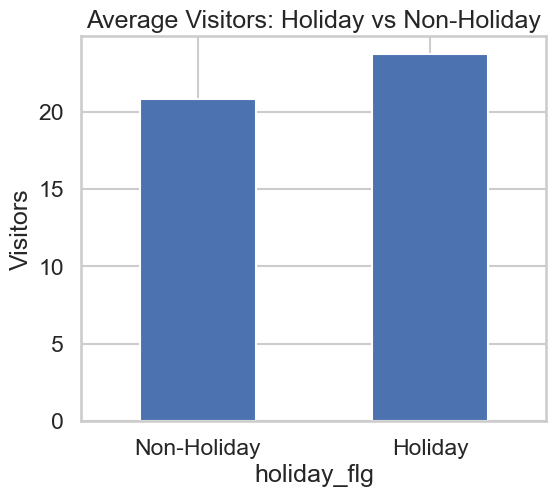

In [46]:
# Cell 10: Holiday effect
date_info['calendar_date'] = pd.to_datetime(date_info['calendar_date'])
merged = train.merge(date_info, left_on="visit_date", right_on="calendar_date", how="left")

holiday_visitors = merged.groupby("holiday_flg")['visitors'].mean()

plt.figure(figsize=(6,5))
holiday_visitors.plot(kind="bar")
plt.title("Average Visitors: Holiday vs Non-Holiday")
plt.xticks([0,1], ["Non-Holiday","Holiday"], rotation=0)
plt.ylabel("Visitors")
plt.show()


## Store Metadata

Genres and areas provide categorical features for forecasting.


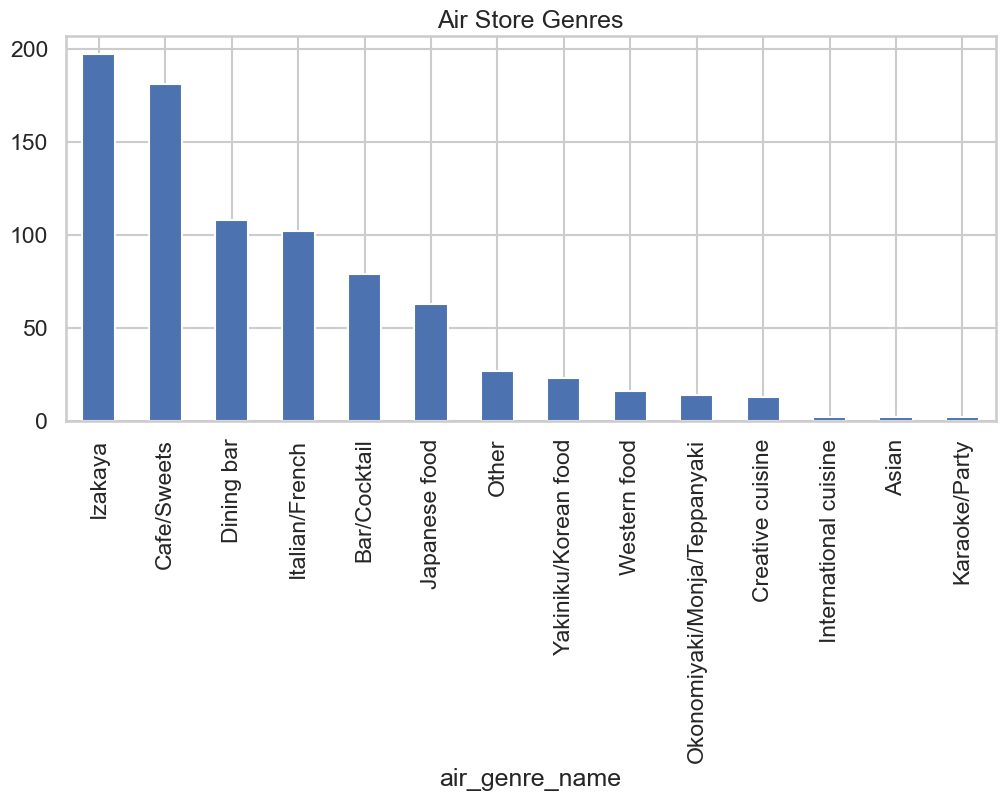

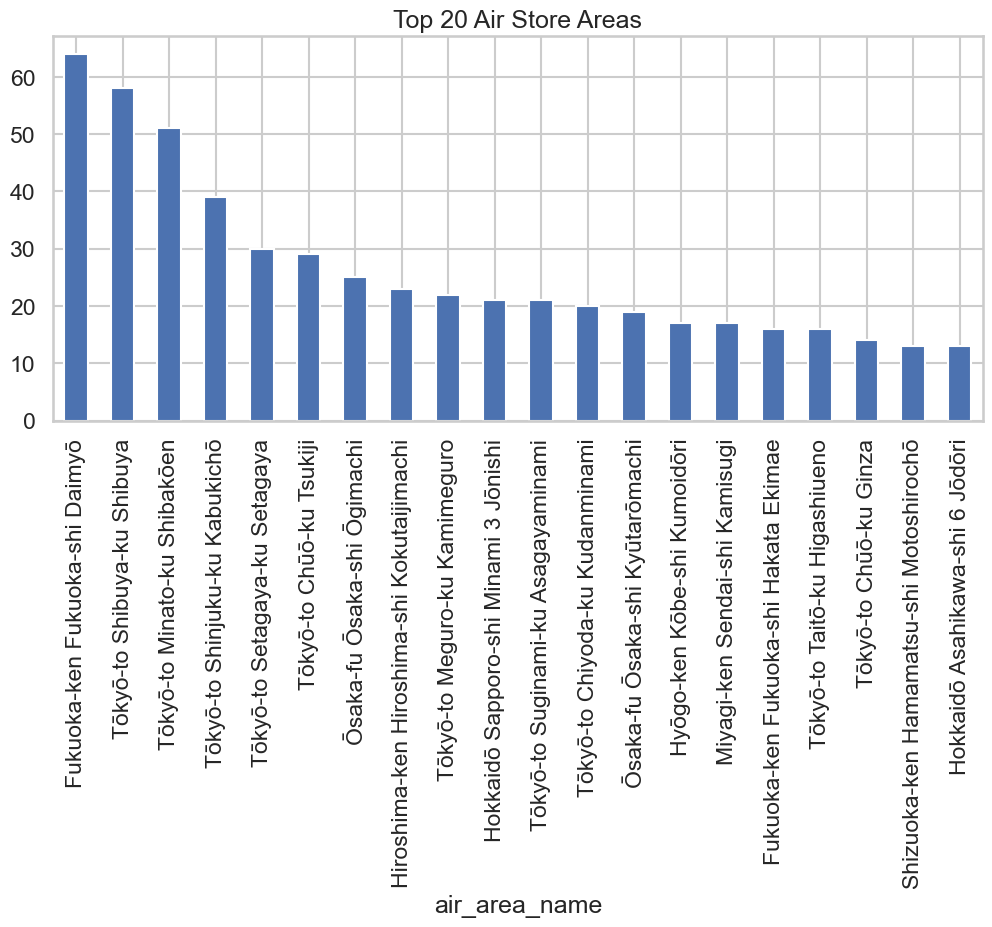

In [47]:
# Cell 11: Air store genres
plt.figure(figsize=(12,5))
air_store_info['air_genre_name'].value_counts().plot(kind="bar")
plt.title("Air Store Genres")
plt.show()

# Cell 12: Air store areas
plt.figure(figsize=(12,5))
air_store_info['air_area_name'].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Air Store Areas")
plt.show()


## Reservations Data

Reservations may help explain spikes in visitor counts.


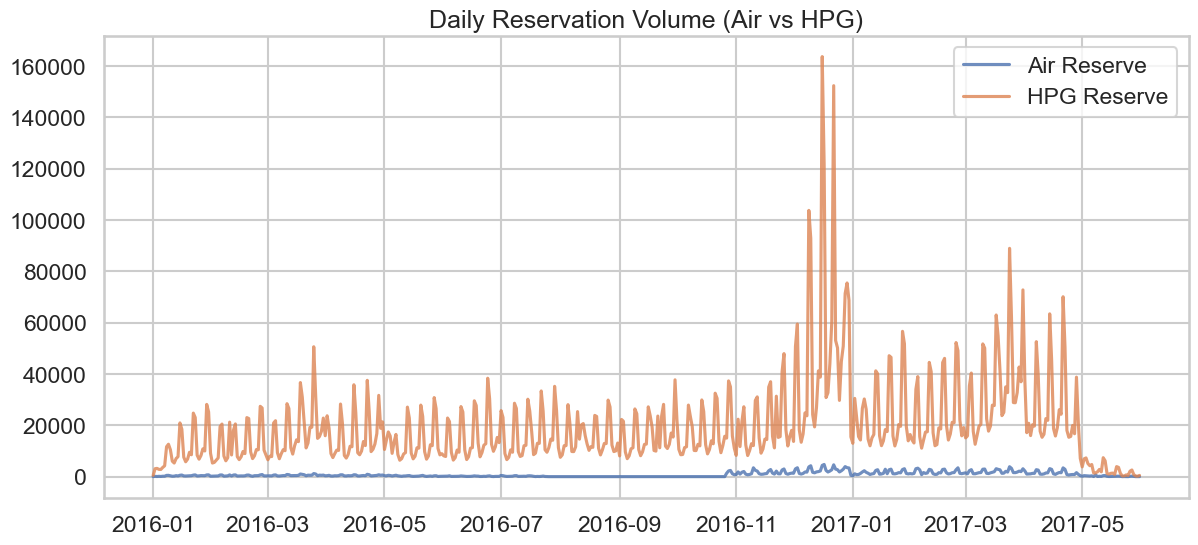

In [48]:
# Cell 13: Reservations daily volume
air_reserve['visit_datetime'] = pd.to_datetime(air_reserve['visit_datetime'])
hpg_reserve['visit_datetime'] = pd.to_datetime(hpg_reserve['visit_datetime'])

air_reserve_daily = air_reserve.groupby(air_reserve['visit_datetime'].dt.date)['reserve_visitors'].sum()
hpg_reserve_daily = hpg_reserve.groupby(hpg_reserve['visit_datetime'].dt.date)['reserve_visitors'].sum()

plt.figure(figsize=(14,6))
plt.plot(air_reserve_daily.index, air_reserve_daily.values, label="Air Reserve", alpha=0.8)
plt.plot(hpg_reserve_daily.index, hpg_reserve_daily.values, label="HPG Reserve", alpha=0.8)
plt.legend()
plt.title("Daily Reservation Volume (Air vs HPG)")
plt.show()


## Cross-System Relations

We link Air and HPG stores via `store_id_relation`.


In [49]:
# Cell 14: Join Air & HPG store info
merged = store_id_relation.merge(air_store_info, on="air_store_id", how="left") \
                          .merge(hpg_store_info, on="hpg_store_id", how="left")

print("Joined store info sample:")
print(merged.head())


Joined store info sample:
           air_store_id          hpg_store_id                air_genre_name  \
0  air_63b13c56b7201bd9  hpg_4bc649e72e2a239a                   Cafe/Sweets   
1  air_a24bf50c3e90d583  hpg_c34b496d0305a809                    Dining bar   
2  air_c7f78b4f3cba33ff  hpg_cd8ae0d9bbd58ff9  Okonomiyaki/Monja/Teppanyaki   
3  air_947eb2cae4f3e8f2  hpg_de24ea49dc25d6b8                       Izakaya   
4  air_965b2e0cf4119003  hpg_653238a84804d8e7                       Izakaya   

                             air_area_name  latitude_x  longitude_x  \
0           Fukuoka-ken Fukuoka-shi Daimyō   33.586994   130.394894   
1  Shizuoka-ken Hamamatsu-shi Motoshirochō   34.710895   137.725940   
2             Tōkyō-to Minato-ku Shibakōen   35.658068   139.751599   
3    Fukuoka-ken Fukuoka-shi Hakata Ekimae   33.591358   130.414878   
4            Tōkyō-to Meguro-ku Kamimeguro   35.641463   139.698171   

  hpg_genre_name                           hpg_area_name  latitude_y  \


# 📌 Takeaways

* Data is clean (no missing values).  
* Visitor counts are skewed with rare spikes → challenging target.  
* Strong **calendar effects** (day-of-week, holidays).  
* Reservations data helps explain spikes.  
* Store metadata (genre, area) is rich but inconsistent — good candidate for LLM normalization.  

**LangGraph pipeline design**:
- **Cleaner node** → schema normalization, type casting.  
- **LLM node** → categorical normalization (genres/areas).  
- **Forecaster node** → ARIMA/Prophet with calendar + reservations.  
- **Human review node** → handle spikes/outliers with low confidence.  
